In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

In [ ]:
data = pd.read_csv('hawai_co2.csv',header=None, names=['CO2'])
data.index = pd.date_range(start='1959-01-31', periods=len(data), freq='ME')
data = data['CO2']
data

1959-01-31    315.42
1959-02-28    316.31
1959-03-31    316.50
1959-04-30    317.56
1959-05-31    318.13
               ...  
1997-08-31    362.57
1997-09-30    360.24
1997-10-31    360.83
1997-11-30    362.49
1997-12-31    364.34
Freq: ME, Name: CO2, Length: 468, dtype: float64

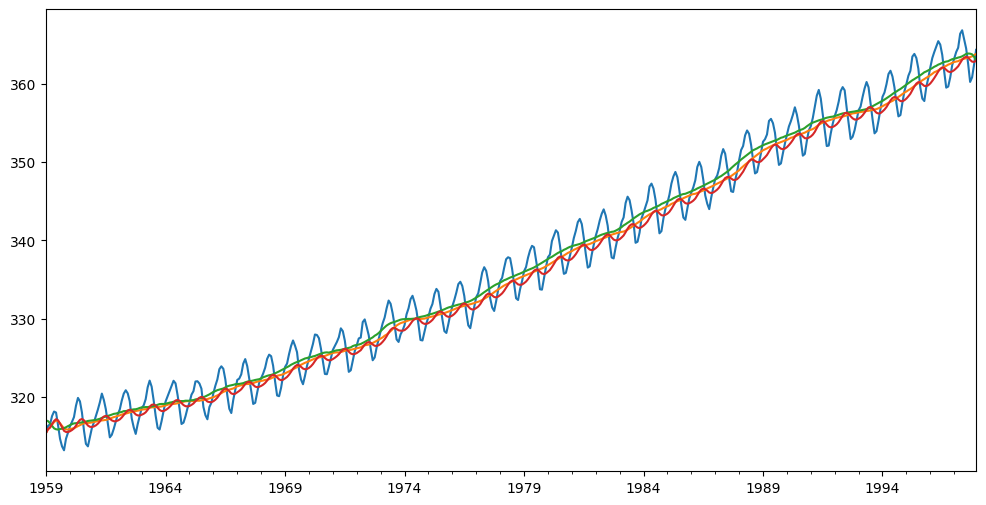

In [8]:
plt.figure(figsize=(12, 6))
data.plot()
data.rolling(window=12,min_periods=1).mean().plot()
data.rolling(window=12,center=True,min_periods=1).mean().plot()
data.ewm(alpha=0.1).mean().plot()
plt.show()

smoothed error: 1.393532581328022
forecast error: 35.900572062852994


<Axes: >

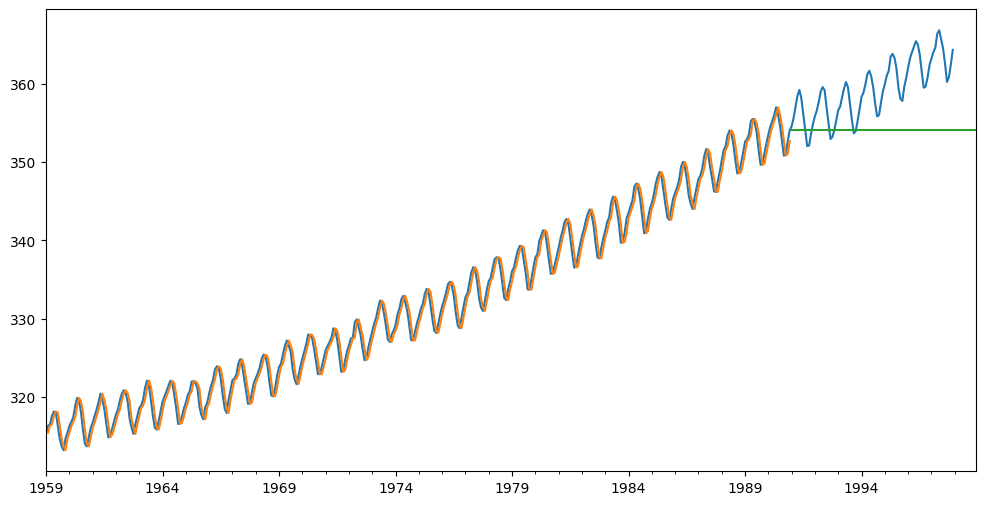

In [9]:
model = SimpleExpSmoothing(data[:"1990"])
fit = model.fit()
smoothed = fit.fittedvalues
forecast = fit.forecast(96)

print("smoothed error:",mean_squared_error(data[:"1990"], smoothed))
print("forecast error:",mean_squared_error(data["1990":], forecast))
plt.figure(figsize=(12, 6))
data.plot()
smoothed.plot()
forecast.plot()

smoothed error: 0.8215909053335048
forecast error: 5127.424894582371


<Axes: >

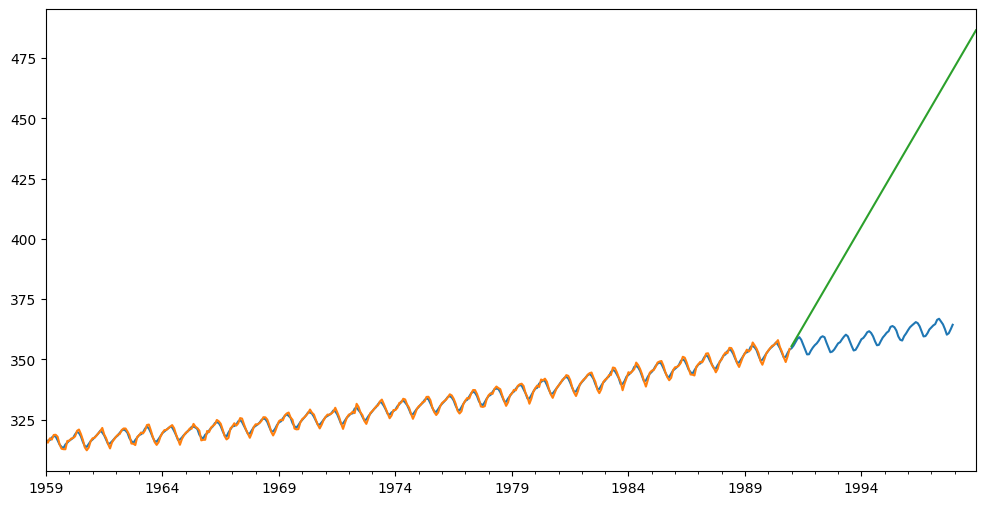

In [10]:
model = Holt(data[:"1990"])
fit = model.fit()
smoothed = fit.fittedvalues
forecast = fit.forecast(96)

print("smoothed error:",mean_squared_error(data[:"1990"], smoothed))
print("forecast error:",mean_squared_error(data["1990":], forecast))
plt.figure(figsize=(12, 6))
data.plot()
smoothed.plot()
forecast.plot()

smoothed error: 0.07521082308821579
forecast error: 3.358702398031911


<Axes: >

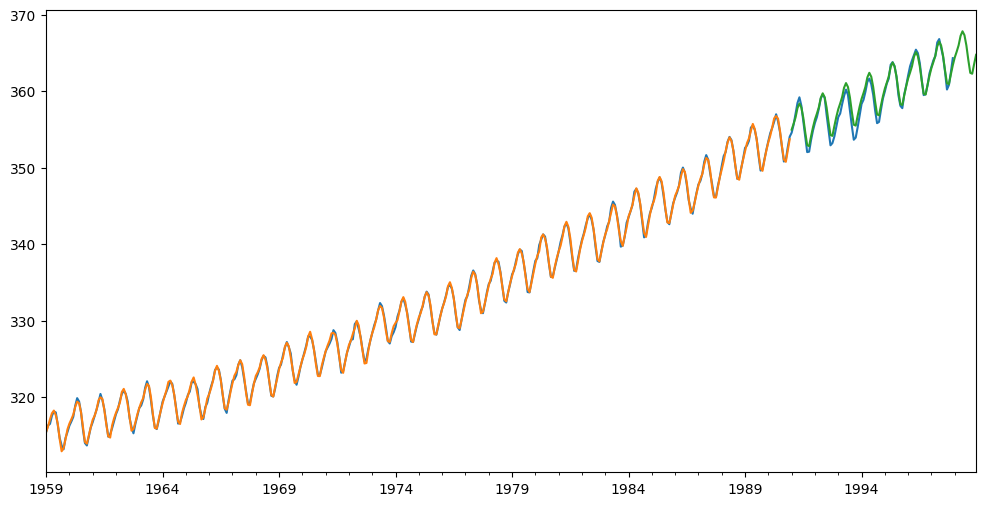

In [11]:
model = ExponentialSmoothing(data[:"1990"],trend='mul', seasonal='add', seasonal_periods=12)
fit = model.fit()
smoothed = fit.fittedvalues
forecast = fit.forecast(96)

print("smoothed error:",mean_squared_error(data[:"1990"], smoothed))
print("forecast error:",mean_squared_error(data["1990":], forecast))
plt.figure(figsize=(12, 6))
data.plot()
smoothed.plot()
forecast.plot()

In [17]:
data = pd.read_csv('co2.csv',header=None, names=['CO2'])
data.index = pd.date_range(start='1959-01-31', periods=len(data), freq='ME')

<Axes: >

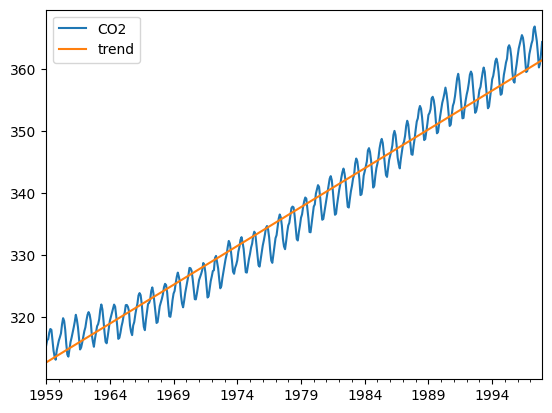

In [18]:
X = [ i + 3000 for i in range(len(data.index)) ]
model = sm.OLS(data.values, X )
res = model.fit()
data['trend'] = res.fittedvalues
data.plot()

<Axes: >

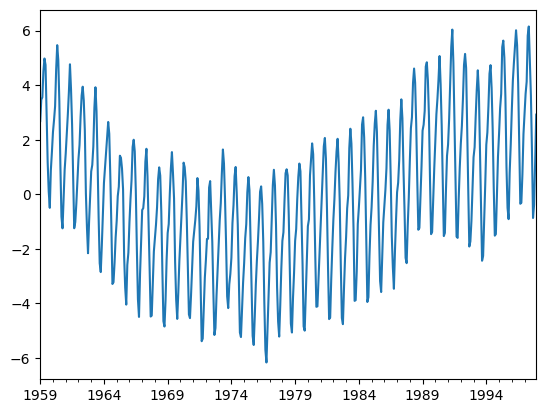

In [20]:
data['residual'] = data['CO2'] - data['trend']
data.residual.plot()

<Axes: >

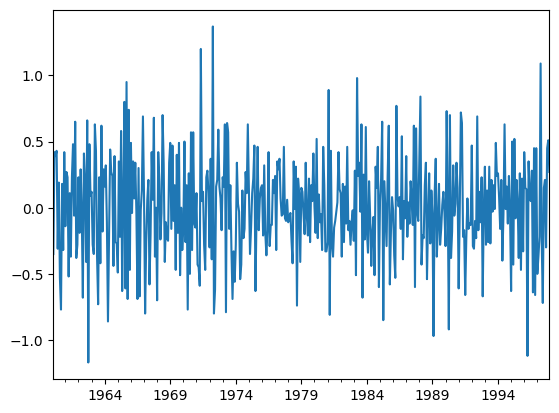

In [22]:
sm.tsa.statespace.tools.diff(data['CO2'], k_diff=1, k_seasonal_diff=1,seasonal_periods=12).plot()

<Axes: >

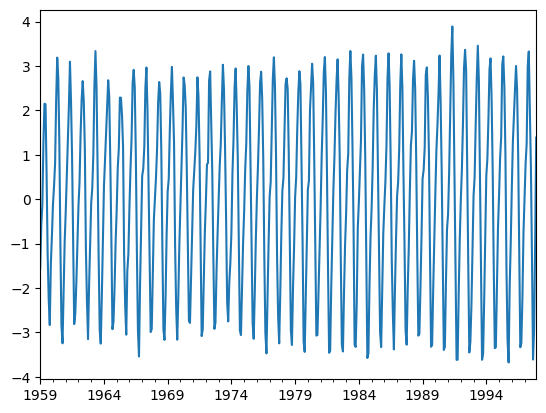

In [24]:
data["residual"] = data["CO2"] - data["CO2"].rolling(window=12, min_periods=1,center=True).mean()
data.residual.plot()

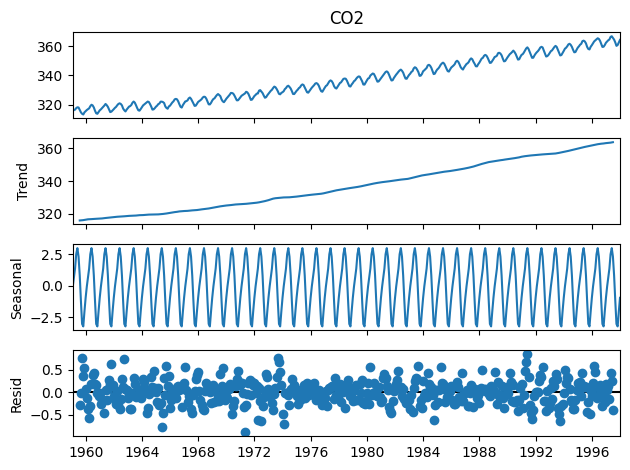

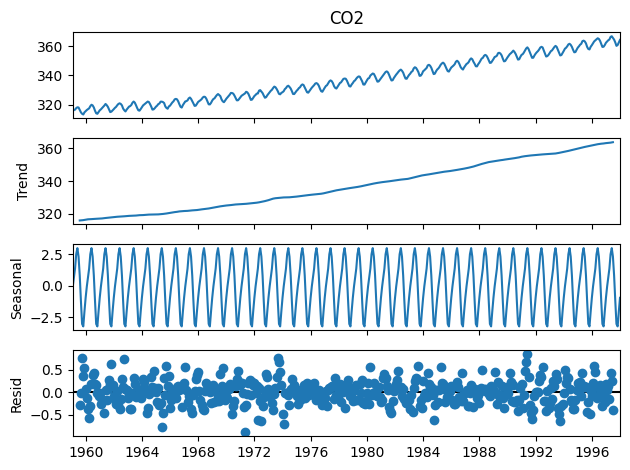

In [25]:
sm.tsa.seasonal_decompose(data['CO2'], model='additive', period=12).plot()